<a href="https://colab.research.google.com/github/firlyfauzi-design/marketing_channel_analysis/blob/main/Marketing_Channel_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing Channel Performance Analysis




## [MARKETINGCHANNELANALYSIS.CSV](https://drive.google.com/file/d/1zeWvo9uQOlkG02lrHXWuEel87Pbe4tiz/view?usp=sharing)


In [105]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/firlyfauzi-design/marketing_channel_analysis/refs/heads/main/marketing_channel_analysis.csv"

df = pd.read_csv(url)

## Project Overview



This project aims to analyze marketing campaign performance across different marketing channels, campaign types, and customer segments.

The objective is to identify factors that contribute to higher conversion rates and provide actionable recommendations for improving marketing effectiveness.

## Business Objective



The main objective of this analysis is to evaluate the effectiveness of marketing campaigns and identify opportunities to improve conversion performance.

Key focus areas include:

- Marketing channel effectiveness
- Campaign type performance
- Advertising spend efficiency
- Customer demographic analysis
- Cost efficiency evaluation

## Data Understanding




### Dataset Summary

- Number of Records: 8,000
- Number of Features: 20
- Missing Values: 0
- Duplicate Records: 0

The dataset is clean and ready for analysis.

In [106]:
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [107]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


In [108]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning



The dataset was checked for missing values and duplicate records.

Results:
- Missing Values: 0
- Duplicate Records: 0

No additional cleaning steps were required.

## Exploratory Data Analysis (EDA)

### Which marketing channel has the highest conversion rate?

In [109]:
channel_conversion = (
    df.groupby('CampaignChannel')['Conversion']
    .mean()
    .sort_values(ascending=False)
)

channel_conversion

,Conversion
CampaignChannel,
Referral,0.883072
PPC,0.882779
SEO,0.876774
Email,0.870263
Social Media,0.868334


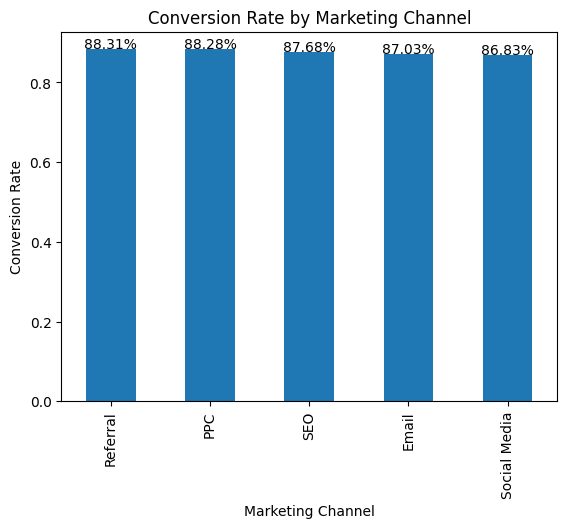

In [110]:
import matplotlib.pyplot as plt

ax = channel_conversion.plot(kind='bar')

plt.title('Conversion Rate by Marketing Channel')
plt.ylabel('Conversion Rate')
plt.xlabel('Marketing Channel')

for i, v in enumerate(channel_conversion):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')

plt.show()

### Which campaign type generates the highest conversion rate?

In [111]:
campaign_conversion = (
    df.groupby('CampaignType')['Conversion']
    .mean()
    .sort_values(ascending=False)
)

campaign_conversion

,Conversion
CampaignType,
Conversion,0.933558
Retention,0.858243
Consideration,0.855634
Awareness,0.855634


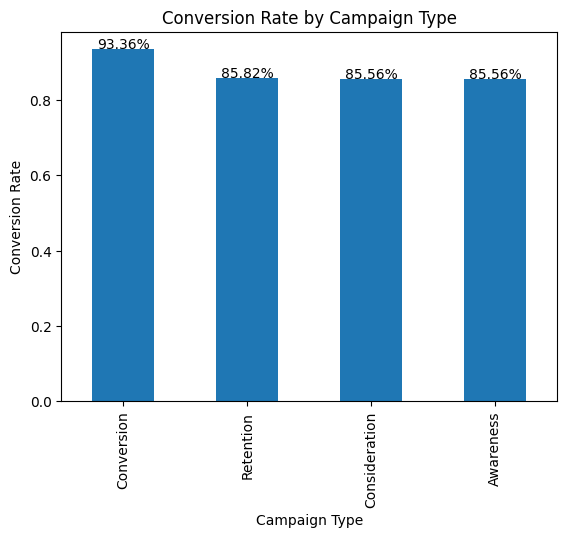

In [112]:
import matplotlib.pyplot as plt

ax = campaign_conversion.plot(kind='bar')

plt.title('Conversion Rate by Campaign Type')
plt.ylabel('Conversion Rate')
plt.xlabel('Campaign Type')

for i, v in enumerate(campaign_conversion):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')

plt.show()

### Does higher advertising spend lead to more conversions?

In [113]:
df[['AdSpend','Conversion']].corr()

,AdSpend,Conversion
AdSpend,1.000000,0.124672
Conversion,0.124672,1.000000


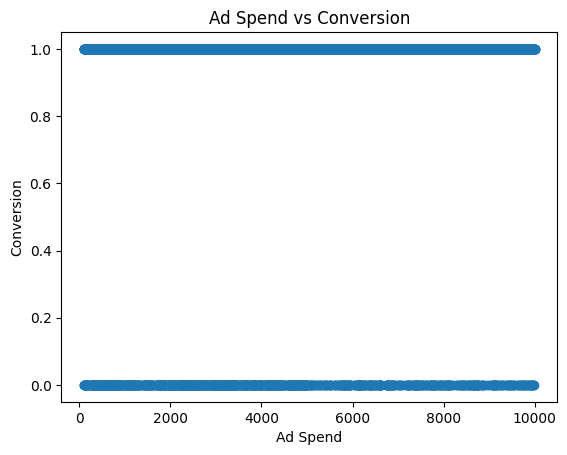

In [114]:
import matplotlib.pyplot as plt

plt.scatter(df['AdSpend'], df['Conversion'])

plt.title('Ad Spend vs Conversion')
plt.xlabel('Ad Spend')
plt.ylabel('Conversion')

plt.show()

###Which customer demographic group has the highest conversion rate?

In [115]:
gender_conversion = (
    df.groupby('Gender')['Conversion']
    .mean()
    .sort_values(ascending=False)
)

gender_conversion

,Conversion
Gender,
Male,0.876938
Female,0.876214


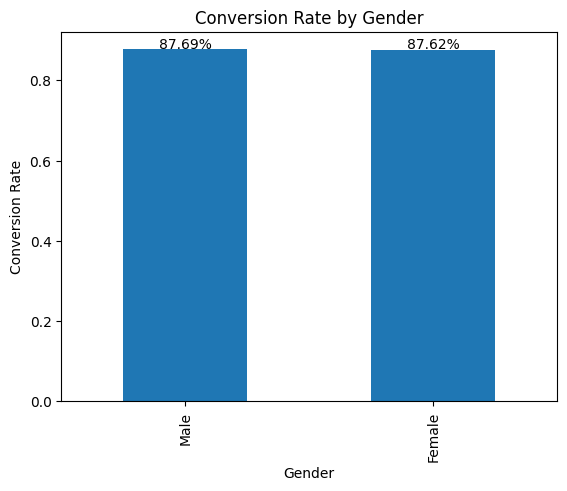

In [116]:
import matplotlib.pyplot as plt

ax = gender_conversion.plot(kind='bar')

plt.title('Conversion Rate by Gender')
plt.ylabel('Conversion Rate')
plt.xlabel('Gender')

for i, v in enumerate(gender_conversion):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')

plt.show()

In [117]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65']
)

In [118]:
age_conversion = (
    df.groupby('AgeGroup')['Conversion']
    .mean()
    .sort_values(ascending=False)
)

age_conversion

/tmp/ipykernel_3680/2635996908.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Conversion']


,Conversion
AgeGroup,
36-45,0.901435
56-65,0.881622
26-35,0.871222
46-55,0.865885
18-25,0.860287


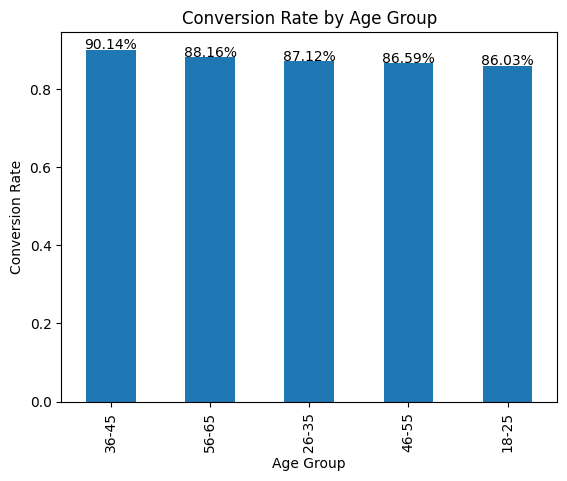

In [119]:
ax = age_conversion.plot(kind='bar')

plt.title('Conversion Rate by Age Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Age Group')

for i, v in enumerate(age_conversion):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')

plt.show()

###Which marketing channel is the most cost-efficient?

In [120]:
channel_efficiency = df.groupby('CampaignChannel').agg({
    'AdSpend': 'mean',
    'Conversion': 'mean'
}).sort_values('Conversion', ascending=False)

channel_efficiency

,AdSpend,Conversion
CampaignChannel,,
Referral,5034.042284,0.883072
PPC,4954.221741,0.882779
SEO,4994.131533,0.876774
Email,5055.604272,0.870263
Social Media,4965.321428,0.868334


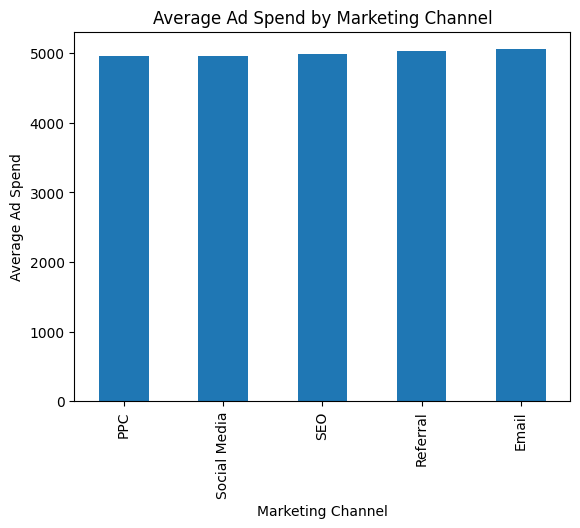

In [121]:
import matplotlib.pyplot as plt

channel_efficiency['AdSpend'].sort_values().plot(kind='bar')

plt.title('Average Ad Spend by Marketing Channel')
plt.ylabel('Average Ad Spend')
plt.xlabel('Marketing Channel')

plt.show()

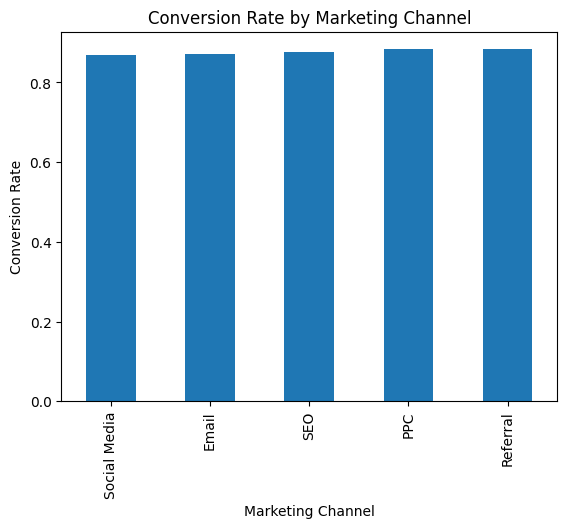

In [122]:
channel_efficiency['Conversion'].sort_values().plot(kind='bar')

plt.title('Conversion Rate by Marketing Channel')
plt.ylabel('Conversion Rate')
plt.xlabel('Marketing Channel')

plt.show()

## Key Insights



1. Referral marketing achieved the highest conversion rate among all marketing channels.

2. PPC campaigns consistently demonstrated strong conversion performance.

3. Campaign type had a measurable impact on conversion outcomes.

4. Customer demographics showed relatively small differences in conversion behavior.

5. Marketing efficiency should be evaluated alongside advertising spend.

## Recommendations




1. Increase investment in referral marketing programs.

2. Continue optimizing PPC campaigns.

3. Conduct further audience segmentation analysis.

4. Monitor advertising spend efficiency rather than focusing solely on budget increases.

5. Implement campaign testing to improve conversion performance.

## Conclusion




This analysis evaluated marketing campaign performance using conversion metrics, advertising spend, and customer characteristics.

Referral and PPC channels demonstrated the strongest performance, while overall conversion rates remained relatively consistent across marketing channels.

Future analyses should incorporate revenue and customer lifetime value metrics to provide a more comprehensive evaluation of marketing effectiveness.